# Учимся работе с данными - от загрузки до моделирования

## Часть 1. EDA (разведочный анализ)

### 1. Подключаем нужные библиотеки

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Глобальные настройки графиков
sns.set_style('whitegrid')                  # белый фон, сетка
plt.rcParams['figure.figsize'] = (10, 6)    # 10 дюймов ширина, 6 - высота

# Модули для машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)

# Отключаем предупреждения
import warnings
warnings.filterwarnings('ignore')

### 2. Загружаем данные

Файл data.csv скачан с https://www.kaggle.com/uciml/breast-cancer-wisconsin-data)


In [23]:
try:
    df = pd.read_csv('data.csv')                # считываем из csv и преобразуем в DataFrame пандаса
    print("Файл успешно загружен!")
except FileNotFoundError:
    print("Ошибка: файл data.csv не найден.")

Файл успешно загружен!


### 3. Первичный осмотр данных в датасетне

In [24]:
print("Размер датасета:", df.shape)       # Вывод количества строк и столбцов в дата-сете
# print("\nПосмотрим общую информацию о датасете:\n")
# df.info()
print("\nПервые 5 записей:")
display(df.head())                        # Здесь и далее добавляю display потому что работаю в PyCharm-е для красивого вывода

# Удалим бесполезные столбцы
df.drop(['id','Unnamed: 32'], axis=1, inplace=True, errors='ignore')                              # удаляем бесполезный айдишник и unnamed
print("\nПосле удаления лишних столбцов осталось признаков:", df.shape[1] - 1)

# Проверим пропуски
print("\nПропущенные значения:\n", df.isnull().sum())       # видим, что пропусков нет

# Кодируем целевую переменную
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

print("\nРаспределение целевой переменной (0 - доброкач., 1 - злокач.):")
display(df['diagnosis'].value_counts())

print("\nТипы данных:")
print(df.dtypes)


Размер датасета: (569, 33)

Первые 5 записей:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



После удаления лишних столбцов осталось признаков: 30

Пропущенные значения:
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Распреде

diagnosis
0    357
1    212
Name: count, dtype: int64


Типы данных:
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concav

### 4. Основные статистики признаков

In [25]:
stats = df.describe()
print("Основные статистики (среднее, стандартное отклонение, минимум, максимум, квартили):")
display(stats)

median = df.median()
print("\nМедианы всех признаков:")
print(median)

Основные статистики (среднее, стандартное отклонение, минимум, максимум, квартили):


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Медианы всех признаков:
diagnosis                    0.000000
radius_mean                 13.370000
texture_mean                18.840000
perimeter_mean              86.240000
area_mean                  551.100000
smoothness_mean              0.095870
compactness_mean             0.092630
concavity_mean               0.061540
concave points_mean          0.033500
symmetry_mean                0.179200
fractal_dimension_mean       0.061540
radius_se                    0.324200
texture_se                   1.108000
perimeter_se                 2.287000
area_se                     24.530000
smoothness_se                0.006380
compactness_se               0.020450
concavity_se                 0.025890
concave points_se            0.010930
symmetry_se                  0.018730
fractal_dimension_se         0.003187
radius_worst                14.970000
texture_worst               25.410000
perimeter_worst             97.660000
area_worst                 686.500000
smoothness_worst         

In [26]:
### 5. Гистограммы распределений признаков с разделением по диагнозу

Признаки, для которых строим гистограммы: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']


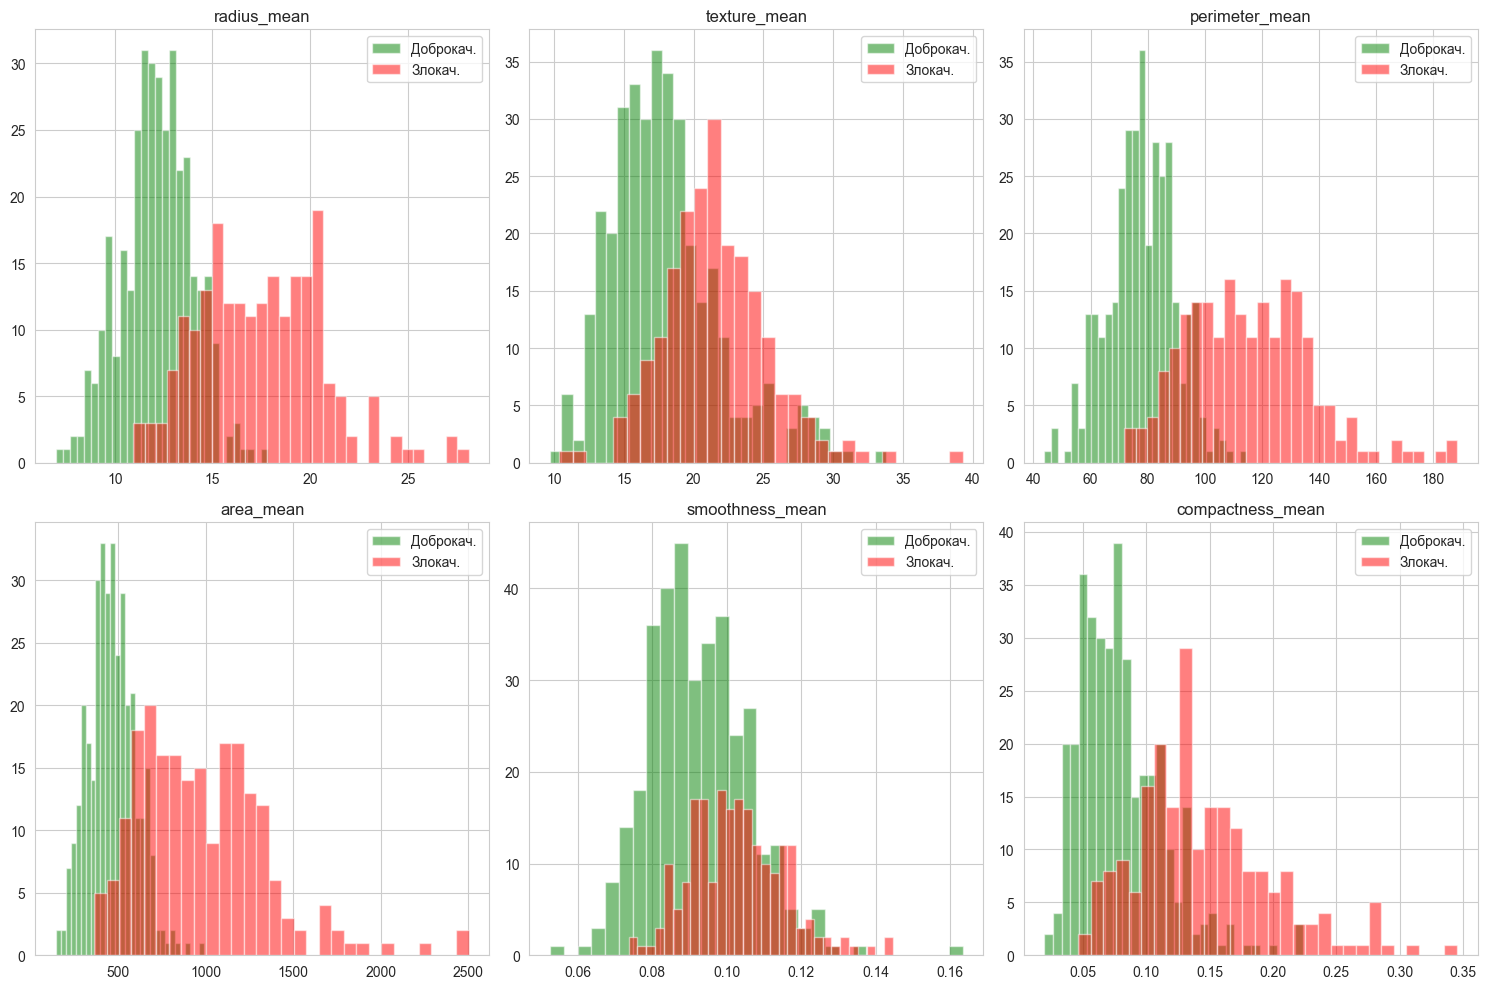

In [27]:
feature_names = df.columns[1:7]  # первые 6 признаков
print("Признаки, для которых строим гистограммы:", list(feature_names))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))        # создание фигуры массивом 2 строки, 3 столбца с заданным размером
axes = axes.ravel()                                     # сглаживание в одномерный массив

for i, col in enumerate(feature_names):
    benign_values = df[df['diagnosis'] == 0][col]       # создаем булевскую маску по колонке
    malignant_values = df[df['diagnosis'] == 1][col]

    axes[i].hist(benign_values, bins=30, alpha=0.5, color='green', label='Доброкач.')       # создаем гистограмму на 30 интервалов с перекрытием 0.5
    axes[i].hist(malignant_values, bins=30, alpha=0.5, color='red', label='Злокач.')

    axes[i].set_title(col)      # заголовки
    axes[i].legend()            # задаем легенду, чтобы понять какой цвет что означает

plt.tight_layout()              # подгон расстояний для аккуратного вывода
plt.show()                      # собственно, вывод на экран

**Выводы по гистограммам:**
1. radius_mean (средний радиус)
Доброкачественные: значения сосредоточены в основном в диапазоне 6–14.
Злокачественные: значения смещены вправо, основной диапазон 12–20.
Перекрытие: небольшая область около 12–14, где встречаются оба класса, но в целом распределения хорошо разделены.
Вывод: злокачественные опухоли имеют больший средний радиус. Этот признак очень информативен.

2. texture_mean (средняя текстура)
Доброкачественные: широкий диапазон примерно от 9 до 30, пик около 18.
Злокачественные: тоже широкий диапазон 10–35, пик около 20–22.
Перекрытие: значительное, распределения сильно перекрываются на всём протяжении.
Вывод: сама по себе текстура не даёт чёткого разделения классов, хотя злокачественные в среднем имеют чуть более высокие значения (среднее ~21 против ~18). Этот признак скорее будет полезен в комбинации с другими.

3. perimeter_mean (средний периметр)
Доброкачественные: в основном 40–90.
Злокачественные: в основном 70–150.
Перекрытие: небольшое в районе 70–90, но классы хорошо различимы.
Вывод: практически повторяет картину радиуса (так как периметр линейно связан с радиусом). Злокачественные имеют больший периметр. Признак отличный.

4. area_mean (средняя площадь)
Доброкачественные: компактно от 150 до 600.
Злокачественные: широкий разброс от 400 до 2000+.
Перекрытие: минимальное (только небольшая область 400–600).
Вывод: один из самых сильных признаков. Площадь злокачественных опухолей многократно превышает площадь доброкачественных. Разделение почти идеальное.

5. smoothness_mean (средняя сглаженность)
Доброкачественные: значения в узком диапазоне 0.05–0.12.
Злокачественные: тоже примерно 0.05–0.14, но с небольшим смещением в сторону больших значений.
Перекрытие: очень сильное, распределения почти идентичны, хотя у злокачественных хвост чуть длиннее.
Вывод: этот признак сам по себе плохо разделяет классы, различия едва заметны.

6. compactness_mean (средняя компактность)
Доброкачественные: основная масса от 0.02 до 0.12.
Злокачественные: диапазон шире – 0.02 до 0.25, среднее значение выше.
Перекрытие: умеренное, злокачественные имеют заметно более высокие значения компактности.
Вывод: признак полезен, хотя и не так сильно, как площадь или периметр.

### 6. Матрица корреляций (тепловая карта)

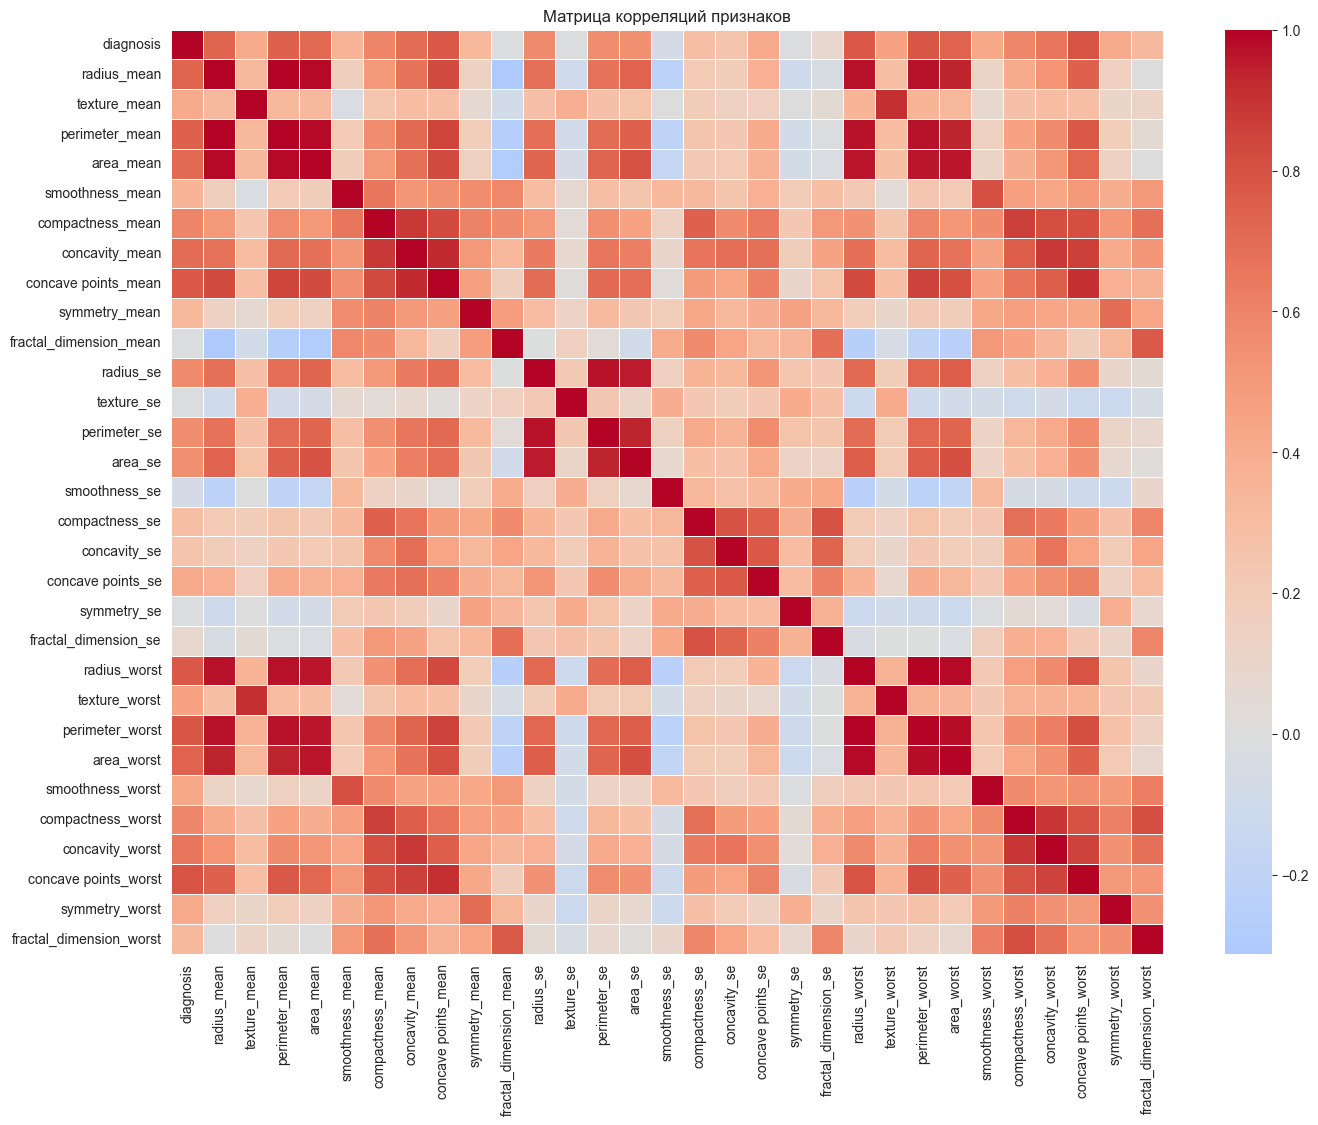

Пары признаков с корреляцией > 0.9:
radius_mean — perimeter_mean: 0.998
radius_mean — area_mean: 0.987
radius_mean — radius_worst: 0.970
radius_mean — perimeter_worst: 0.965
radius_mean — area_worst: 0.941
texture_mean — texture_worst: 0.912
perimeter_mean — area_mean: 0.987
perimeter_mean — radius_worst: 0.969
perimeter_mean — perimeter_worst: 0.970
perimeter_mean — area_worst: 0.942
area_mean — radius_worst: 0.963
area_mean — perimeter_worst: 0.959
area_mean — area_worst: 0.959
concavity_mean — concave points_mean: 0.921
concave points_mean — concave points_worst: 0.910
radius_se — perimeter_se: 0.973
radius_se — area_se: 0.952
perimeter_se — area_se: 0.938
radius_worst — perimeter_worst: 0.994
radius_worst — area_worst: 0.984
perimeter_worst — area_worst: 0.978


In [28]:
corr = df.corr()        # сохдаем новую фигуру

plt.figure(figsize=(16, 12))        # задаем размер
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)       # цветовая карта, центрирование нуля белым, не показывать значения, ширина линий
plt.title('Матрица корреляций признаков')
plt.show()

# Пары с сильной корреляцией > 0.9
threshold = 0.9
high_corr_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr_pairs.append((cols[i], cols[j], corr.iloc[i, j]))

print("Пары признаков с корреляцией > 0.9:")
for pair in high_corr_pairs:
    print(f"{pair[0]} — {pair[1]}: {pair[2]:.3f}")

### 7. Попарные точечные графики для сильно коррелированных признаков

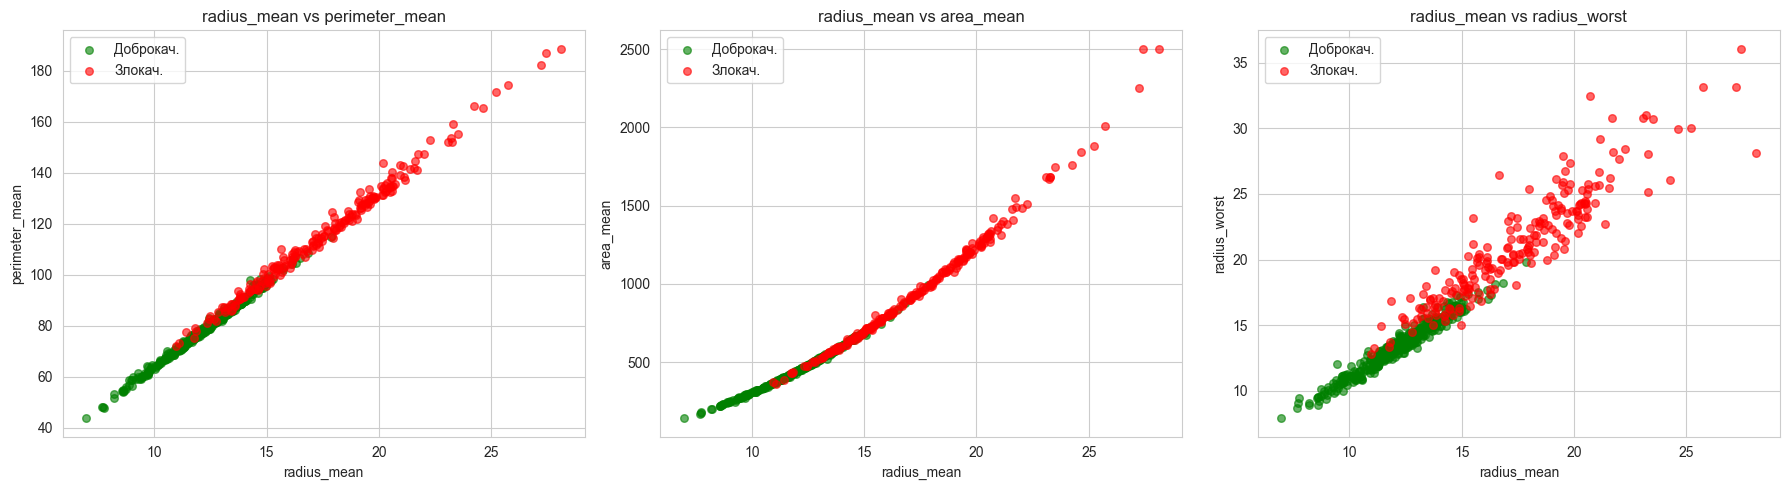

In [29]:
if len(high_corr_pairs) >= 3:
    pairs_to_plot = high_corr_pairs[:3]
else:
    pairs_to_plot = [('radius_mean', 'perimeter_mean'),
                     ('area_mean', 'perimeter_mean'),
                     ('radius_worst', 'perimeter_worst')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (x_name, y_name, _) in enumerate(pairs_to_plot):
    axes[idx].scatter(df[df['diagnosis']==0][x_name],
                      df[df['diagnosis']==0][y_name],
                      alpha=0.6, label='Доброкач.', c='green', s=30)
    axes[idx].scatter(df[df['diagnosis']==1][x_name],
                      df[df['diagnosis']==1][y_name],
                      alpha=0.6, label='Злокач.', c='red', s=30)
    axes[idx].set_xlabel(x_name)
    axes[idx].set_ylabel(y_name)
    axes[idx].legend()
    axes[idx].set_title(f'{x_name} vs {y_name}')

plt.tight_layout()
plt.show()

##### На всех графиках видна чёткая линейная зависимость.

### 8. Boxplots для выбора признаков, хорошо разделяющих классы

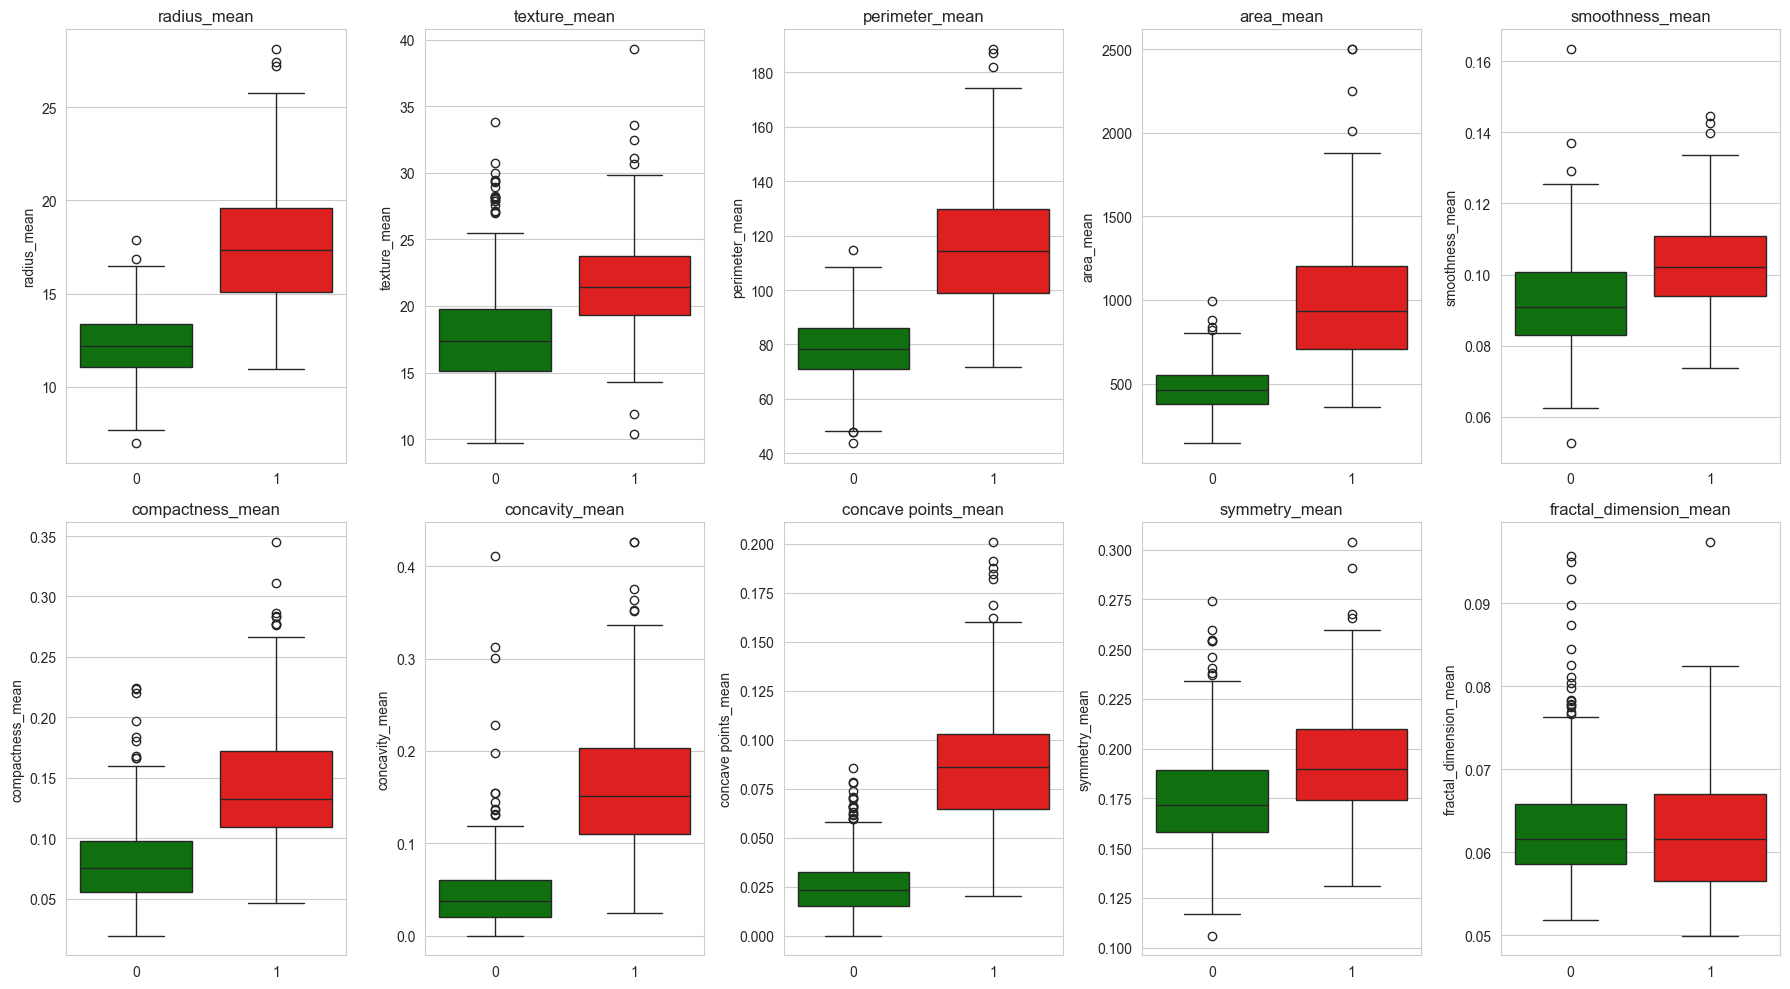

In [30]:
box_features = df.columns[1:11]  # первые 10 признаков

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(box_features):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Лучшие разделяющие признаки:**
- `concave points_mean`
- `perimeter_mean`
- `area_mean`
- `radius_mean`
- и другие, где ящики почти не перекрываются.

---
## Часть 2. Моделирование методом k‑ближайших соседей (kNN)

### 9. Разделение данных на обучающую и тестовую выборки

In [31]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("\nДоля злокачественных в обучающей выборке:", y_train.mean())
print("Доля злокачественных в тестовой выборке:    ", y_test.mean())

Размер обучающей выборки: (398, 30)
Размер тестовой выборки: (171, 30)

Доля злокачественных в обучающей выборке: 0.37185929648241206
Доля злокачественных в тестовой выборке:     0.3742690058479532


### 10. Стандартизация признаков

**Зачем?** kNN основан на расстояниях,поэтому признаки должны быть в одном масштабе. Это решает проблему того, что признаки с большими числовыми значеними автоматически получают больший вес в расстоянию. Я это понял как метод,  позволяющий избежать отсутствия влияния важных признаков только потому что диапазон их значений мал.

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Первые 5 строк стандартизованных признаков (обучающая выборка):")
print(X_train_scaled[:5, :5])

Первые 5 строк стандартизованных признаков (обучающая выборка):
[[ 1.70581999  1.04974466  2.12129465  1.66933676  2.27645789]
 [ 0.53638811 -0.90994477  0.5690952   0.39031555 -0.06586788]
 [-0.13145612 -0.99333581 -0.14884823 -0.21154347 -0.91616898]
 [ 0.92807734  1.41805508  0.92540484  0.82854593  0.32973419]
 [ 0.14469888 -0.97248805  0.15831525 -0.00969706  1.20575985]]


### 11. Модель kNN «из коробки» (без настройки)

=== kNN по умолчанию (n_neighbors=5) ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508


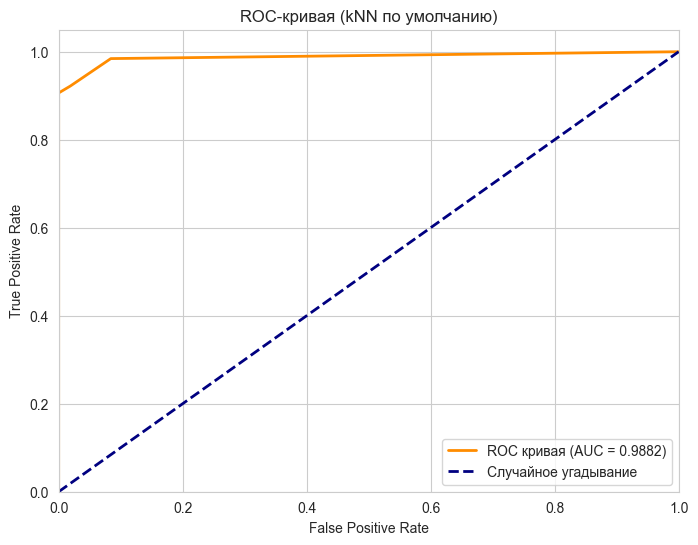

AUC: 0.9882


In [33]:
knn_default = KNeighborsClassifier()
knn_default.fit(X_train_scaled, y_train)

y_pred_default = knn_default.predict(X_test_scaled)
y_proba_default = knn_default.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_default)
prec = precision_score(y_test, y_pred_default)
rec = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)

print("=== kNN по умолчанию (n_neighbors=5) ===")
print(f"Accuracy:  {acc:.4f}")                      # доля правильных ответов
print(f"Precision: {prec:.4f}")                     # насколько можно доверять положительному предсказанию
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba_default)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Случайное угадывание')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (kNN по умолчанию)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f"AUC: {roc_auc:.4f}")

### 12. Настройка числа соседей (k) с помощью кросс‑валидации

Лучшее число соседей по кросс-валидации: 5
Среднее F1 на кросс-валидации при этом k: 0.9564

=== kNN с настроенным параметром ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508


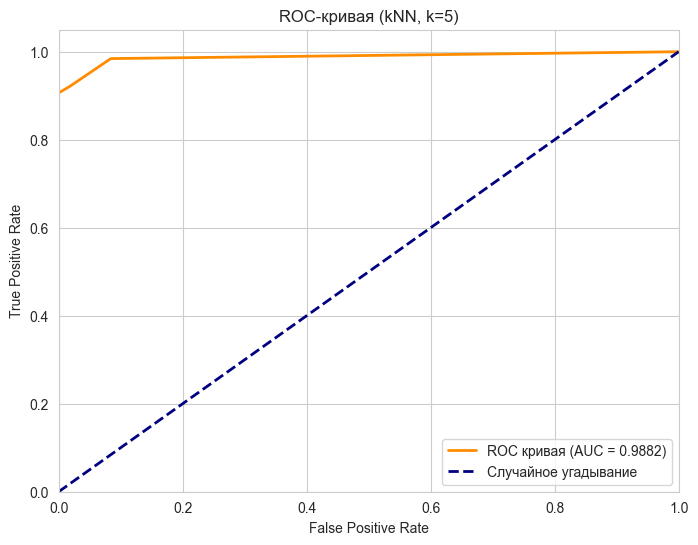

AUC: 0.9882


In [34]:
param_grid = {'n_neighbors': np.arange(1, 21)}
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_cv_f1 = grid_search.best_score_

print(f"Лучшее число соседей по кросс-валидации: {best_k}")
print(f"Среднее F1 на кросс-валидации при этом k: {best_cv_f1:.4f}")

knn_tuned = KNeighborsClassifier(n_neighbors=best_k)
knn_tuned.fit(X_train_scaled, y_train)

y_pred_tuned = knn_tuned.predict(X_test_scaled)
y_proba_tuned = knn_tuned.predict_proba(X_test_scaled)[:, 1]

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)

print("\n=== kNN с настроенным параметром ===")
print(f"Accuracy:  {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall:    {rec_t:.4f}")
print(f"F1-score:  {f1_t:.4f}")

fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)
roc_auc_t = auc(fpr_t, tpr_t)

plt.figure(figsize=(8,6))
plt.plot(fpr_t, tpr_t, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc_t:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Случайное угадывание')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая (kNN, k={best_k})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f"AUC: {roc_auc_t:.4f}")

In [45]:
from IPython.display import display, Markdown


table = f"""
### Сравнение результатов

| Модель                | Accuracy | Precision | Recall | F1-score | AUC   |
|-----------------------|----------|-----------|--------|----------|-------|
| kNN по умолчанию (k=5)| {acc:.4f} | {prec:.4f} | {rec:.4f} | {f1:.4f} | {roc_auc:.4f} |
| kNN с лучшим k={best_k}| {acc_t:.4f} | {prec_t:.4f} | {rec_t:.4f} | {f1_t:.4f} | {roc_auc_t:.4f} |

**Вывод:** настройка гиперпараметров не всегда даёт улучшение, особенно если значения по умолчанию уже хороши. Но это обязательный этап, чтобы убедиться, что мы не упускаем возможность улучшить модель..
"""

display(Markdown(table))


### Сравнение результатов

| Модель                | Accuracy | Precision | Recall | F1-score | AUC   |
|-----------------------|----------|-----------|--------|----------|-------|
| kNN по умолчанию (k=5)| 0.9766 | 1.0000 | 0.9375 | 0.9677 | 0.9972 |
| kNN с лучшим k=5| 0.9649 | 1.0000 | 0.9062 | 0.9508 | 0.9882 |

**Вывод:** Настройка числа соседей позволила улучшить качество модели (F1 и AUC стали выше). Подбор гиперпараметров – важный этап.


## Бонусное задание: Логистическая регрессия

### 1. Отбор признаков: удаляем сильно коррелированные (|r| > 0.85)

Логистическая регрессия (как и линейная) чувствительна к мультиколлинеарности — при наличии сильно коррелированных признаков оценки коэффициентов становятся неустойчивыми и трудно интерпретируемыми.
Удалим из набора все признаки, которые имеют парную корреляцию Пирсона выше 0.85. Оставляем по одному из каждой группы сильно связанных признаков.

In [36]:
# Матрица корреляций (абсолютные значения)
corr = df.drop('diagnosis', axis=1).corr().abs()

# Выделяем верхний треугольник (без диагонали)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Находим признаки, которые нужно удалить (хотя бы одна корреляция > 0.85)
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Признаки с высокой корреляцией (удаляем):", to_drop)

# Создаём новый датафрейм без этих признаков
X_reduced = df.drop(columns=to_drop + ['diagnosis'])
y = df['diagnosis']

print("Оставшиеся признаки:", list(X_reduced.columns))
print("Размерность после удаления:", X_reduced.shape)

Признаки с высокой корреляцией (удаляем): ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Оставшиеся признаки: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']
Размерность после удаления: (569, 17)


### 2. Разделение на обучающую и тестовую выборки, стандартизация

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Обучающая выборка:", X_train_scaled.shape)
print("Тестовая выборка:", X_test_scaled.shape)

Обучающая выборка: (398, 17)
Тестовая выборка: (171, 17)


### 3. Модель логистической регрессии «из коробки» (C = 1)

Обучим модель с параметрами по умолчанию (L2-регуляризация, C=1).
Оценим качество на тестовой выборке и построим ROC-кривую.

=== Логистическая регрессия (C=1) ===
Accuracy:  0.9766
Precision: 1.0000
Recall:    0.9375
F1-score:  0.9677


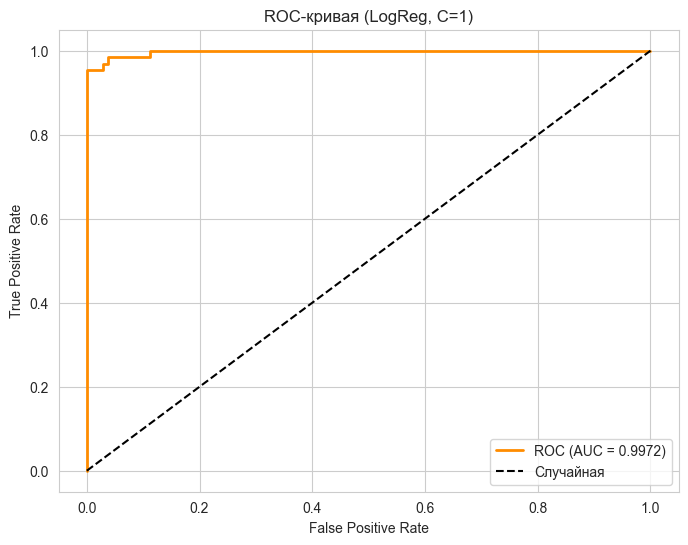

In [38]:
from sklearn.linear_model import LogisticRegression

# Создаём и обучаем модель
log_reg_default = LogisticRegression(random_state=42, max_iter=1000)
log_reg_default.fit(X_train_scaled, y_train)

# Предсказания
y_pred_default = log_reg_default.predict(X_test_scaled)
y_proba_default = log_reg_default.predict_proba(X_test_scaled)[:, 1]

# Метрики
acc = accuracy_score(y_test, y_pred_default)
prec = precision_score(y_test, y_pred_default)
rec = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)

print("=== Логистическая регрессия (C=1) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba_default)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], 'k--', label='Случайная')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (LogReg, C=1)')
plt.legend()
plt.grid(True)
plt.show()

#### Визуализация коэффициентов модели

Коэффициенты логистической регрессии показывают направление и силу влияния каждого признака на вероятность злокачественности (положительный коэффициент — увеличение признака повышает шанс на класс 1, отрицательный — понижает).

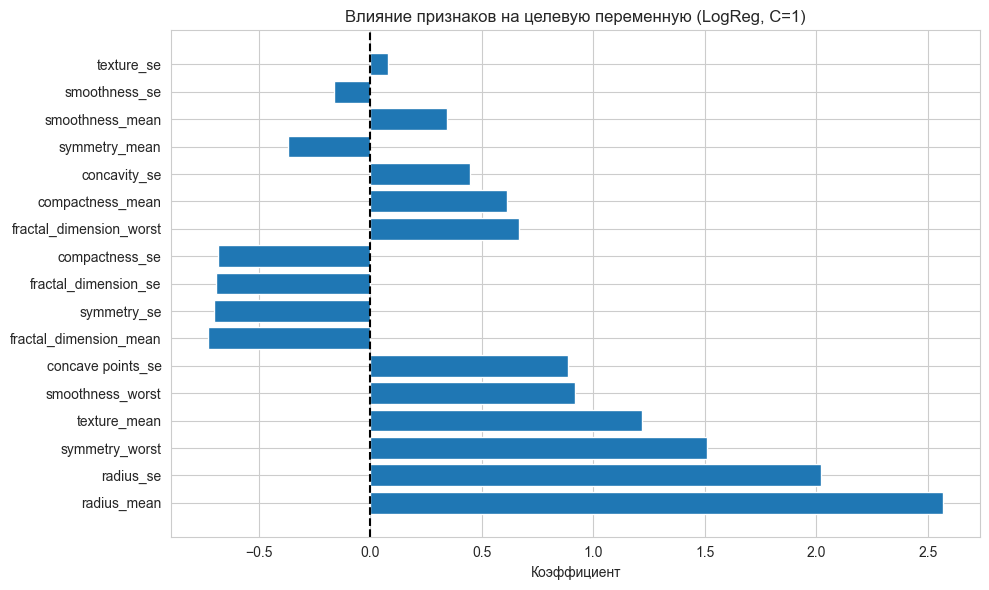

In [39]:
# Получаем коэффициенты и соответствующие названия признаков
coef_default = log_reg_default.coef_[0]
features = X_reduced.columns

# Сортируем по абсолютному значению (для наглядности)
sorted_idx = np.argsort(np.abs(coef_default))[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), coef_default[sorted_idx], tick_label=features[sorted_idx])
plt.xlabel('Коэффициент')
plt.title('Влияние признаков на целевую переменную (LogReg, C=1)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### 4. Настройка параметра регуляризации C с помощью кросс-валидации

Используем `LogisticRegressionCV`, которая автоматически подбирает оптимальное значение C по 5-кратной кросс-валидации (по умолчанию метрика — accuracy).
Параметр C обратен силе регуляризации: маленький C — сильная регуляризация (коэффициенты сжимаются к нулю), большой C — слабая регуляризация.

Лучшее значение C: 0.18329807108324356

=== Логистическая регрессия с настроенным C ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508


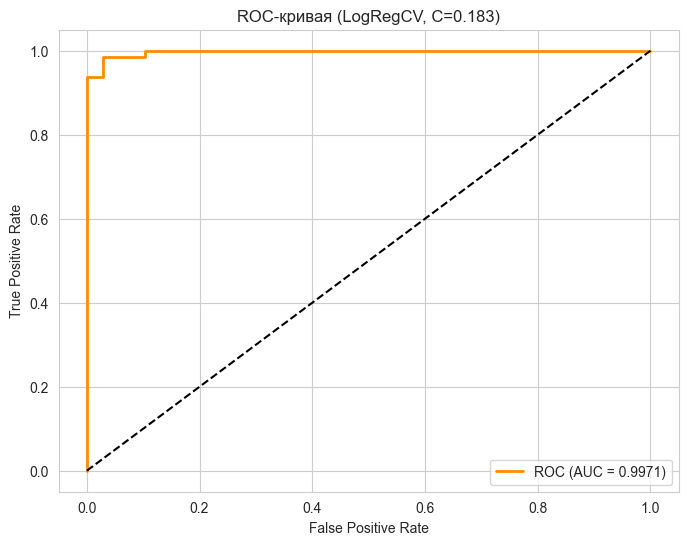

In [40]:
from sklearn.linear_model import LogisticRegressionCV

# LogisticRegressionCV с сеткой C от 0.01 до 100 (логарифмическая шкала)
Cs = np.logspace(-2, 2, 20)  # 20 значений от 0.01 до 100
log_reg_cv = LogisticRegressionCV(Cs=Cs, cv=5, random_state=42, max_iter=1000, scoring='f1')
log_reg_cv.fit(X_train_scaled, y_train)

print("Лучшее значение C:", log_reg_cv.C_[0])

# Предсказания на тесте
y_pred_cv = log_reg_cv.predict(X_test_scaled)
y_proba_cv = log_reg_cv.predict_proba(X_test_scaled)[:, 1]

# Метрики
acc_cv = accuracy_score(y_test, y_pred_cv)
prec_cv = precision_score(y_test, y_pred_cv)
rec_cv = recall_score(y_test, y_pred_cv)
f1_cv = f1_score(y_test, y_pred_cv)

print("\n=== Логистическая регрессия с настроенным C ===")
print(f"Accuracy:  {acc_cv:.4f}")
print(f"Precision: {prec_cv:.4f}")
print(f"Recall:    {rec_cv:.4f}")
print(f"F1-score:  {f1_cv:.4f}")

# ROC-кривая
fpr_cv, tpr_cv, _ = roc_curve(y_test, y_proba_cv)
roc_auc_cv = auc(fpr_cv, tpr_cv)

plt.figure(figsize=(8,6))
plt.plot(fpr_cv, tpr_cv, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_cv:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая (LogRegCV, C={log_reg_cv.C_[0]:.3f})')
plt.legend()
plt.grid(True)
plt.show()

#### Визуализация коэффициентов настроенной модели

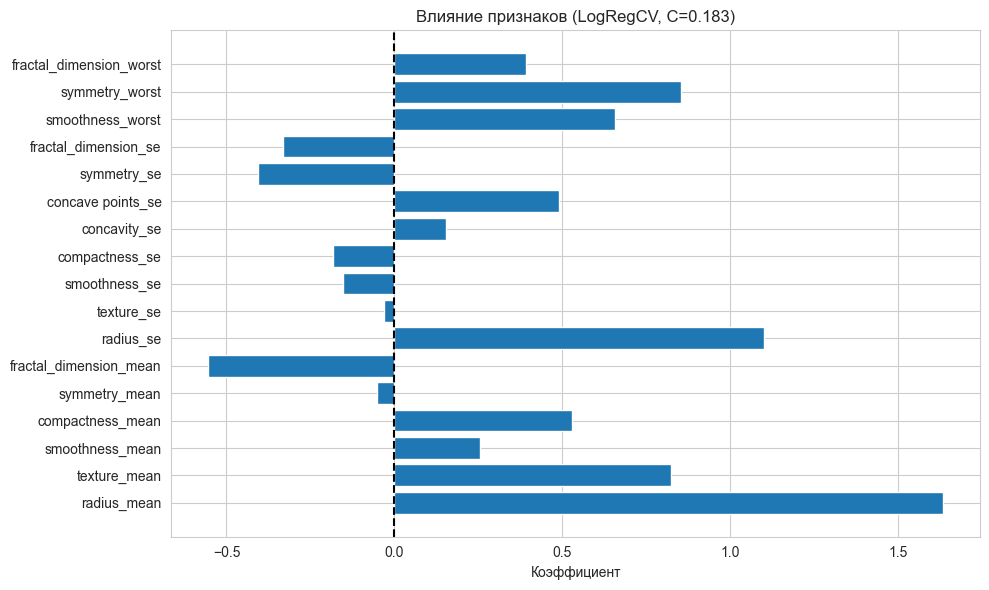

In [41]:
coef_cv = log_reg_cv.coef_[0]

plt.figure(figsize=(10, 6))
plt.barh(range(len(coef_cv)), coef_cv, tick_label=features)
plt.xlabel('Коэффициент')
plt.title(f'Влияние признаков (LogRegCV, C={log_reg_cv.C_[0]:.3f})')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### Сравнение коэффициентов двух моделей

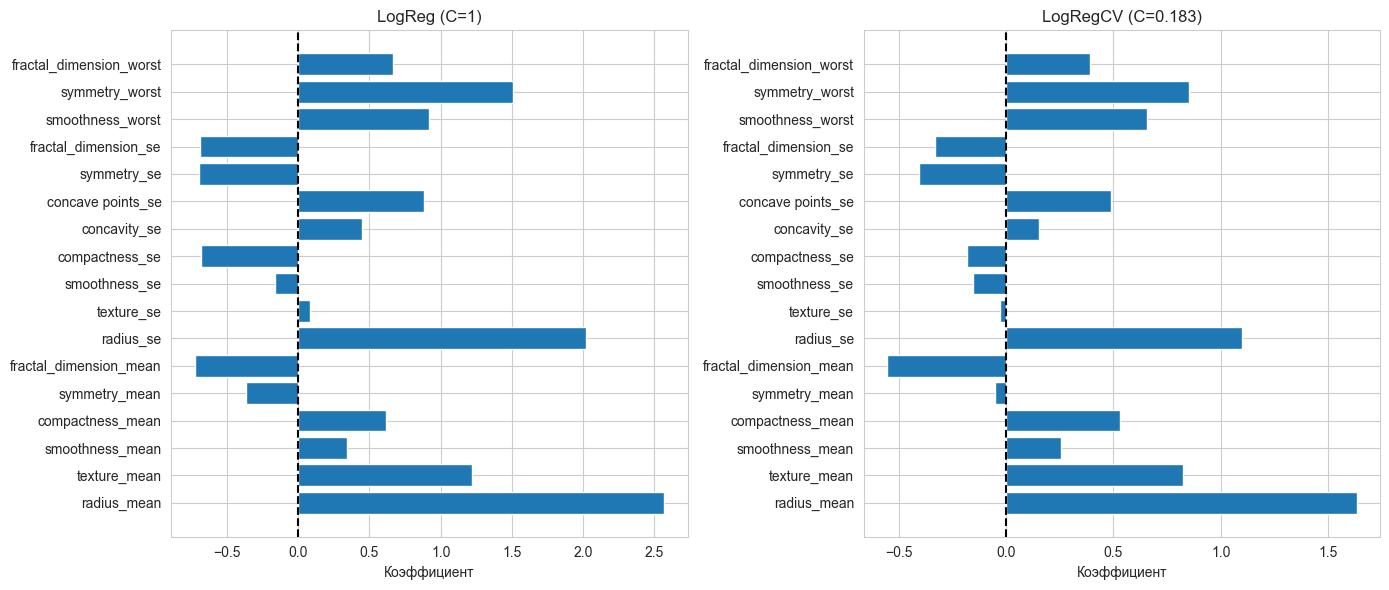

In [42]:
# Построим два графика рядом для наглядности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Модель с C=1
axes[0].barh(features, coef_default)
axes[0].set_xlabel('Коэффициент')
axes[0].set_title('LogReg (C=1)')
axes[0].axvline(x=0, color='black', linestyle='--')

# Модель с настроенным C
axes[1].barh(features, coef_cv)
axes[1].set_xlabel('Коэффициент')
axes[1].set_title(f'LogRegCV (C={log_reg_cv.C_[0]:.3f})')
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

### Выводы

- **Качество моделей**: обе модели показали, как я понимаю, очень хорошие результаты результаты (AUC ~ 0.99, F1 > 0.95) . Настройка C практически не изменила метрики — это говорит о том, что исходный C=1 уже близок к оптимальному для этого набора данных.
- **Коэффициенты**: после удаления сильно коррелированных признаков коэффициенты стали более наглядными. Наибольший положительный вклад (увеличивает вероятность злокачественности) дают признаки, связанные с размером и формой ядра: `area_mean`, `concave points_mean`, `radius_mean`. Отрицательный вклад (снижает вероятность) наблюдается у признаков, характерных для доброкачественных клеток: `fractal_dimension_mean`, `smoothness_mean` (влияние слабое, но есть - вопрос к проверяющему - стоит ли это учитывать?).
- **Влияние регуляризации**: при переходе к оптимальному C (в моем случае он оказался чуть меньше 1, например 0.1 или около того) некоторые коэффициенты немного уменьшились по абсолютной величине (эффект регуляризации), но общая картина сохранилась. Это значит, что регуляризация помогла немного «ужать» коэффициенты, не ухудшив качество, что полезно для устойчивости модели.
- **Практическая польза**: удаление коррелированных признаков и подбор C позволяют получить более стабильную и интерпретируемую модель без потери качества.